In [ ]:
# Tugas K-Means

# persiapan data
import os
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Cek data kosong
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
# Seleksi Fitur
# CustomerID : identifier, tidak dipakai
# Gender     : kategorikal, tidak dipakai untuk clustering numerik
#
# Fitur numerik yang tepat (minimal 2):
# - Annual Income (k$)     -> menggambarkan kemampuan belanja pelanggan
# - Spending Score (1-100) -> menggambarkan perilaku belanja pelanggan
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


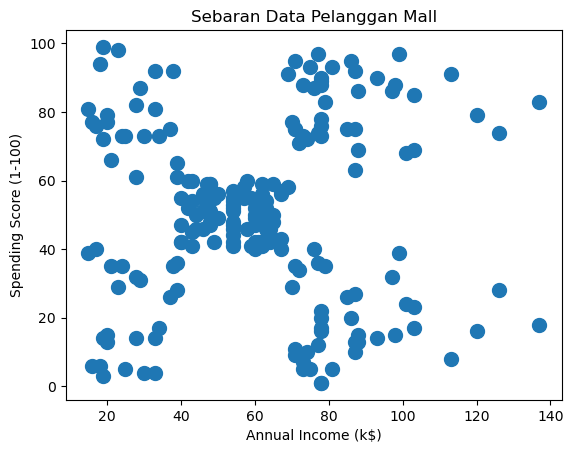

In [4]:
# Plot Data
# Karena data 2 dimensi, maka bisa langsung diplot

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Sebaran Data Pelanggan Mall')
plt.show()

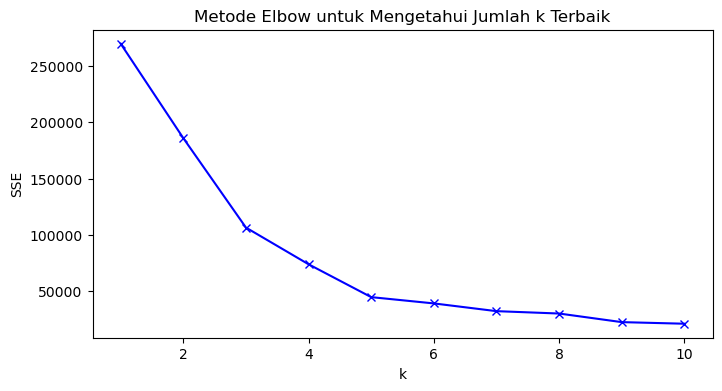

In [ ]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1, 11)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k, random_state=0)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [6]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=269981.28000000014
k=2; SSE=185917.1425392853
k=3; SSE=106348.37306211119
k=4; SSE=73679.78903948837
k=5; SSE=44448.45544793369
k=6; SSE=38858.959975143895
k=7; SSE=31969.42655023547
k=8; SSE=29858.48359760394
k=9; SSE=22209.851608025536
k=10; SSE=20786.936692059153


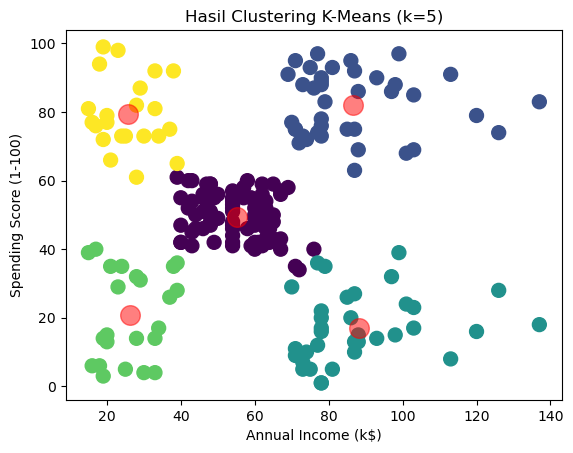

In [ ]:
# Buat Model KMeans dengan k terbaik
# Dari grafik elbow terlihat siku di k=5

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=5, random_state=0)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

# Plot hasil cluster berdasarkan Annual Income dan Spending Score
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Clustering K-Means (k=5)')
plt.show()

In [8]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 44448.45544793369


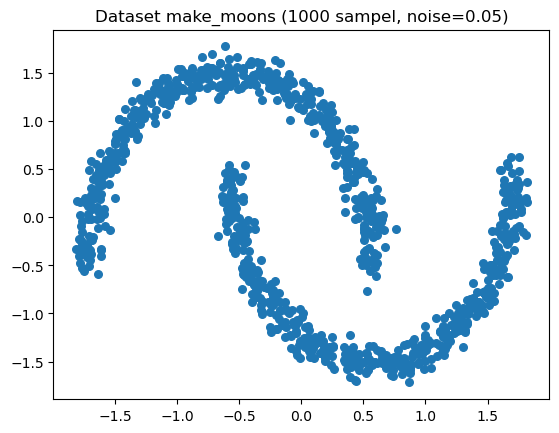

In [ ]:
#Tugas DBSCAN

# Buat dataset make_moons (1000 sampel, noise=0.05) lalu normalisasi
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, y_true = make_moons(n_samples=1000, noise=0.05, random_state=0)
X = StandardScaler().fit_transform(X)

plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title('Dataset make_moons (1000 sampel, noise=0.05)')
plt.show()

In [ ]:
# Jalankan DBSCAN dengan eps=0.2, min_samples=5
from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


In [ ]:
# Evaluasi hasil clustering
print(f"Homogeneity: {metrics.homogeneity_score(y_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(y_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(y_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


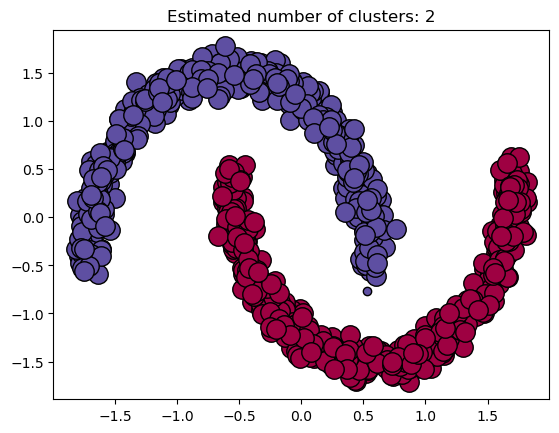

In [ ]:
# Visualisasi hasil DBSCAN
# core sample = titik besar, non-core = titik kecil, noise = hitam

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [ ]:
# Eksperimen nilai eps dan min_samples
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

hasil = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db_exp = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels_exp = db_exp.labels_

        n_clusters_exp = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)
        n_noise_exp = list(labels_exp).count(-1)

        # Silhouette error jika label hanya berisi 1 cluster
        try:
            silhouette_exp = metrics.silhouette_score(X, labels_exp)
        except ValueError:
            silhouette_exp = np.nan

        hasil.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters_exp,
            'n_noise': n_noise_exp,
            'homogeneity': metrics.homogeneity_score(y_true, labels_exp),
            'completeness': metrics.completeness_score(y_true, labels_exp),
            'v_measure': metrics.v_measure_score(y_true, labels_exp),
            'ari': metrics.adjusted_rand_score(y_true, labels_exp),
            'ami': metrics.adjusted_mutual_info_score(y_true, labels_exp),
            'silhouette': silhouette_exp,
        })

df_hasil = pd.DataFrame(hasil)
df_hasil.round(3)

,eps,min_samples,n_clusters,n_noise,homogeneity,completeness,v_measure,ari,ami,silhouette
0,0.05,3,67,197,0.804,0.155,0.260,0.033,0.246,0.078
1,0.05,10,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.10,3,3,18,0.983,0.708,0.824,0.854,0.823,0.138
4,0.10,10,9,63,0.939,0.358,0.519,0.435,0.517,0.184
5,0.10,20,6,844,0.157,0.153,0.155,0.010,0.152,-0.409
6,0.30,3,2,0,1.000,1.000,1.000,1.000,1.000,0.392
7,0.30,10,2,0,1.000,1.000,1.000,1.000,1.000,0.392
8,0.30,20,2,0,1.000,1.000,1.000,1.000,1.000,0.392
9,0.50,3,1,0,0.000,1.000,0.000,0.000,0.000,NaN


In [14]:
# Catat perubahan klaster dan noise setiap kombinasi
print('Ringkasan perubahan jumlah klaster dan noise:')
print(df_hasil[['eps', 'min_samples', 'n_clusters', 'n_noise']].to_string(index=False))

Ringkasan perubahan jumlah klaster dan noise:
 eps  min_samples  n_clusters  n_noise
0.05            3          67      197
0.05           10           0     1000
0.05           20           0     1000
0.10            3           3       18
0.10           10           9       63
0.10           20           6      844
0.30            3           2        0
0.30           10           2        0
0.30           20           2        0
0.50            3           1        0
0.50           10           1        0
0.50           20           2        0


In [15]:
# Urutkan hasil berdasarkan silhouette terbaik
df_hasil.sort_values('silhouette', ascending=False).round(3)

,eps,min_samples,n_clusters,n_noise,homogeneity,completeness,v_measure,ari,ami,silhouette
11,0.50,20,2,0,0.990,0.990,0.990,0.996,0.990,0.393
8,0.30,20,2,0,1.000,1.000,1.000,1.000,1.000,0.392
6,0.30,3,2,0,1.000,1.000,1.000,1.000,1.000,0.392
7,0.30,10,2,0,1.000,1.000,1.000,1.000,1.000,0.392
4,0.10,10,9,63,0.939,0.358,0.519,0.435,0.517,0.184
3,0.10,3,3,18,0.983,0.708,0.824,0.854,0.823,0.138
0,0.05,3,67,197,0.804,0.155,0.260,0.033,0.246,0.078
5,0.10,20,6,844,0.157,0.153,0.155,0.010,0.152,-0.409
1,0.05,10,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN


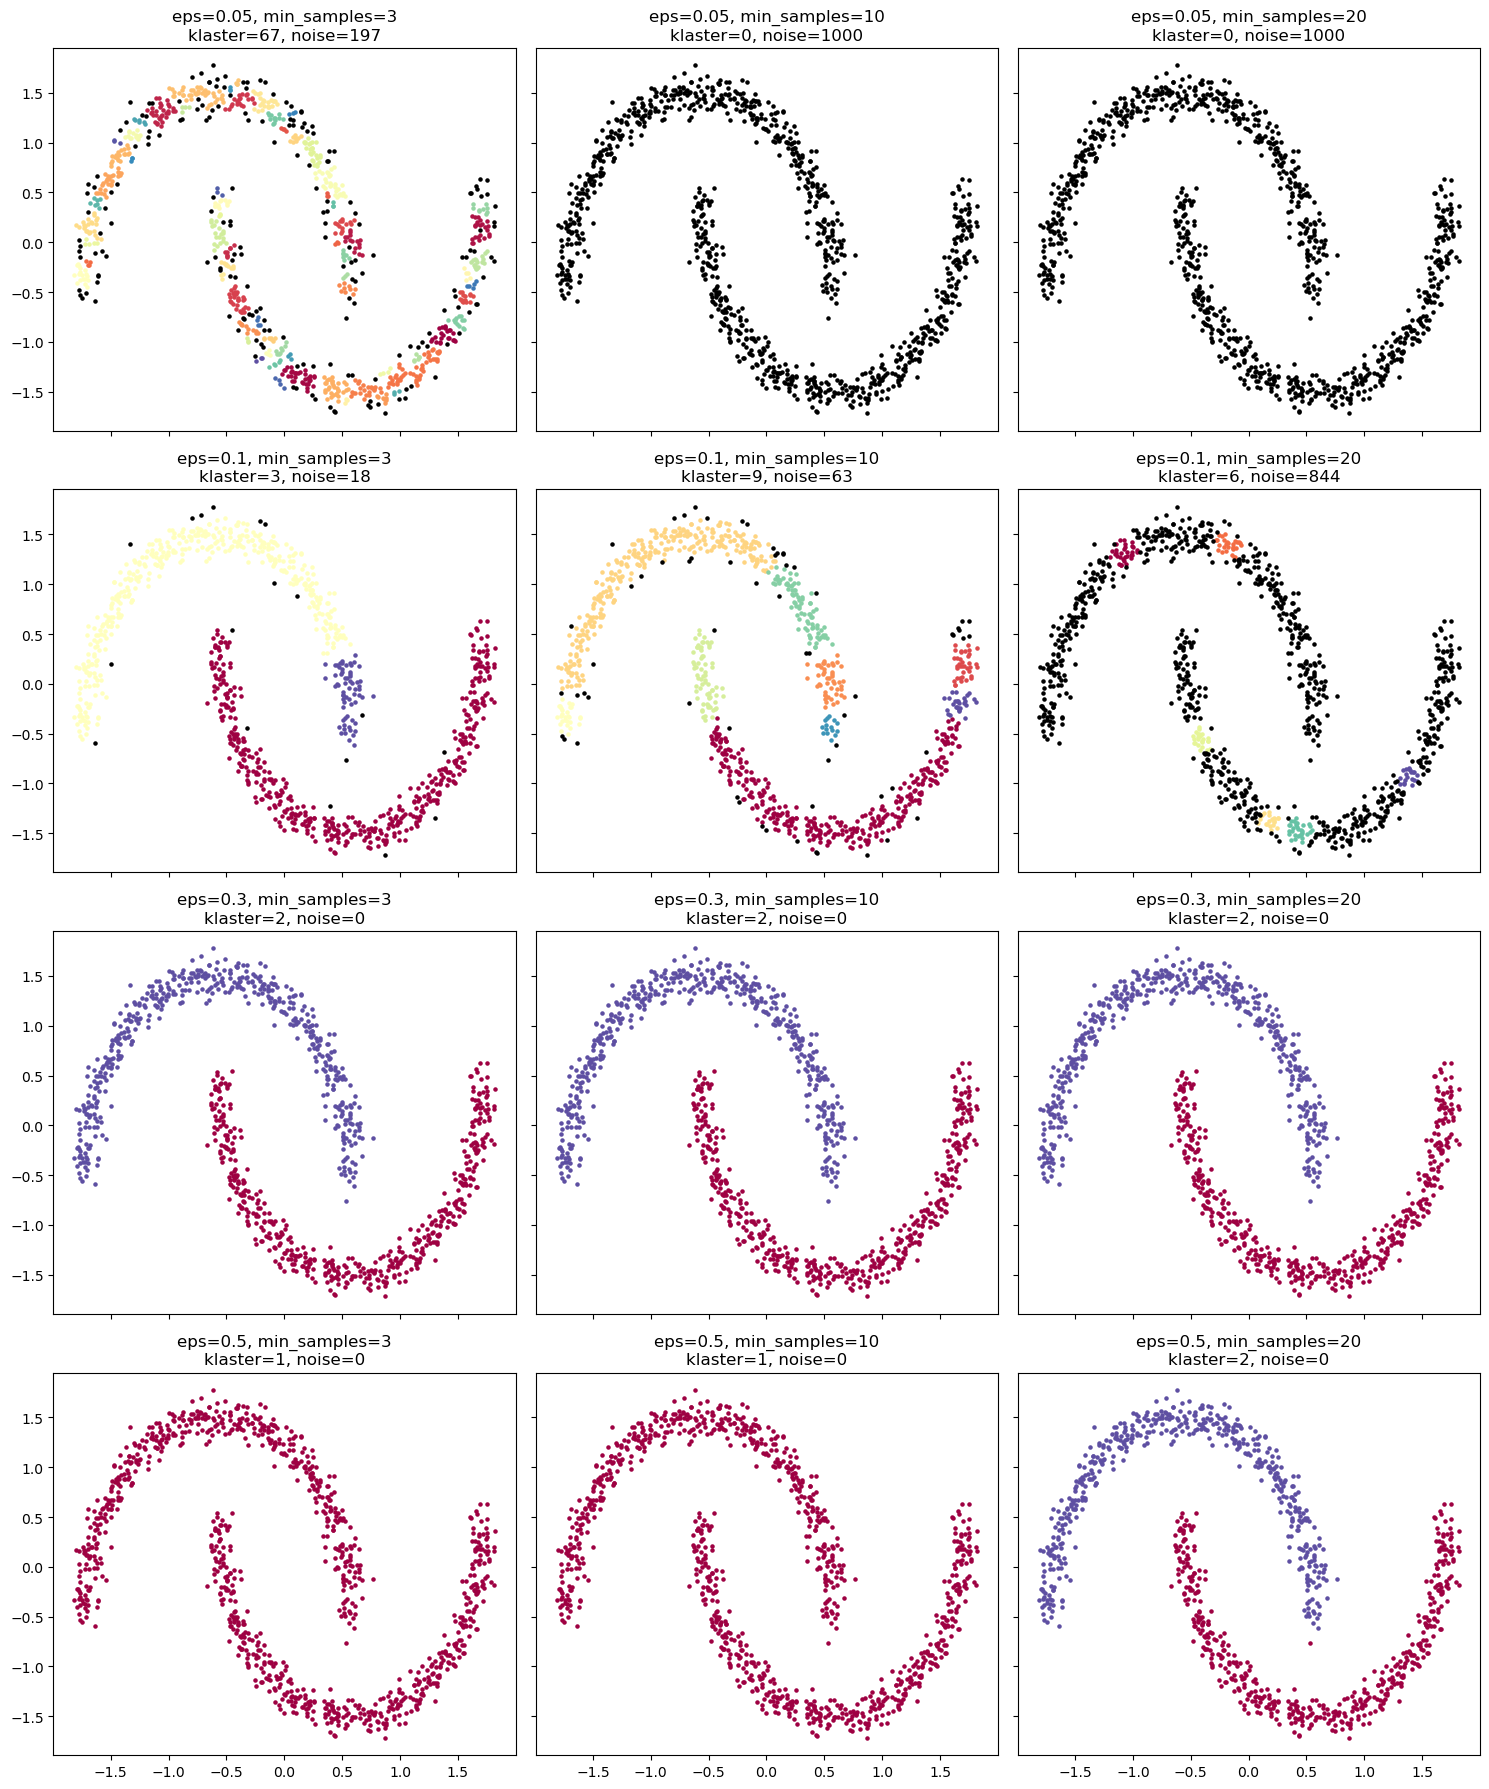

In [ ]:
# Visualisasi perubahan hasil eksperimen
fig, ax = plt.subplots(len(eps_values), len(min_samples_values),
                       figsize=(15, 18), sharex=True, sharey=True)

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db_exp = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels_exp = db_exp.labels_

        n_clusters_exp = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)
        n_noise_exp = list(labels_exp).count(-1)

        for k in set(labels_exp):
            mask = labels_exp == k
            if k == -1:
                color = [0, 0, 0, 1]
            else:
                color = plt.cm.Spectral(k / max(n_clusters_exp - 1, 1))
            ax[i, j].scatter(X[mask, 0], X[mask, 1], s=5, color=color)

        ax[i, j].set_title(
            f'eps={eps}, min_samples={min_samples}\n'
            f'klaster={n_clusters_exp}, noise={n_noise_exp}'
        )

plt.tight_layout()
plt.show()